In [1]:
# Cell 1: Import fundamental libraries and index dataset files
import os
import pandas as pd
import numpy as np

# Define the relative path to the local dataset directory
DATASET_DIR = "./dataset"

# Traverse the directory tree to identify all CSV data files
csv_filepaths = []
for root, directories, files in os.walk(DATASET_DIR):
    for filename in files:
        if filename.endswith(".csv"):
            csv_filepaths.append(os.path.join(root, filename))

# Output the environment status and file indexing results
print("Status: Core libraries imported successfully.")
print(f"Total CSV files discovered within '{DATASET_DIR}': {len(csv_filepaths)}")

# Display a subset of file paths for structural verification
if csv_filepaths:
    print("\nSample of discovered file paths (Top 5):")
    for path in csv_filepaths[:5]:
        print(f" - {path}")
else:
    print("\nError: No CSV files detected. Please verify the directory structure and extraction process.")

Status: Core libraries imported successfully.
Total CSV files discovered within './dataset': 78

Sample of discovered file paths (Top 5):
 - ./dataset\GothamDataset2025\processed\iotsim-air-quality-1.csv
 - ./dataset\GothamDataset2025\processed\iotsim-building-monitor-1.csv
 - ./dataset\GothamDataset2025\processed\iotsim-building-monitor-2.csv
 - ./dataset\GothamDataset2025\processed\iotsim-building-monitor-3.csv
 - ./dataset\GothamDataset2025\processed\iotsim-building-monitor-4.csv


In [2]:
# Cell 2: Load a representative subset to inspect data structure and feature space

# Select the initial dataset file for preliminary exploratory data analysis (EDA)
sample_filepath = csv_filepaths[0]
print(f"Targeting file for structural inspection: {sample_filepath}\n")

# Read the CSV file into a pandas DataFrame
# Note: Employing standard loading for a single file; large-scale integration will require optimization
df_sample = pd.read_csv(sample_filepath)

# Output the dimensional characteristics of the dataset
print(f"Dimensionality (Observations, Features): {df_sample.shape}\n")

# Extract and display the feature nomenclature
print("Identified Feature Set (Column Names):")
print(df_sample.columns.tolist())

# Render the initial records for data type verification
df_sample.head()

Targeting file for structural inspection: ./dataset\GothamDataset2025\processed\iotsim-air-quality-1.csv

Dimensionality (Observations, Features): (55052, 23)

Identified Feature Set (Column Names):
['frame.time', 'frame.len', 'frame.protocols', 'eth.src', 'eth.dst', 'ip.dst', 'ip.src', 'ip.flags', 'ip.ttl', 'ip.proto', 'ip.checksum', 'ip.tos', 'tcp.srcport', 'tcp.dstport', 'tcp.flags', 'tcp.window_size_value', 'tcp.window_size_scalefactor', 'tcp.checksum', 'tcp.options', 'tcp.pdu.size', 'udp.srcport', 'udp.dstport', 'label']


,frame.time,frame.len,frame.protocols,eth.src,eth.dst,ip.dst,ip.src,ip.flags,ip.ttl,ip.proto,...,tcp.dstport,tcp.flags,tcp.window_size_value,tcp.window_size_scalefactor,tcp.checksum,tcp.options,tcp.pdu.size,udp.srcport,udp.dstport,label
0,"Jan 14, 2025 18:40:22.447710000 GMT",67,eth:ethertype:ip:udp:dns,02:42:52:d7:fa:00,0c:6e:9c:16:00:00,192.168.0.2,192.168.18.17,0x02,64,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48322.0,53.0,Benign
1,"Jan 14, 2025 18:40:22.453402000 GMT",83,eth:ethertype:ip:udp:dns,0c:6e:9c:16:00:00,02:42:52:d7:fa:00,192.168.18.17,192.168.0.2,0x02,61,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,48322.0,Benign
2,"Jan 14, 2025 18:40:22.453507000 GMT",90,eth:ethertype:ip:udp:ntp,02:42:52:d7:fa:00,0c:6e:9c:16:00:00,192.168.0.3,192.168.18.17,0x02,64,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46343.0,123.0,Benign
3,"Jan 14, 2025 18:40:22.458119000 GMT",90,eth:ethertype:ip:udp:ntp,0c:6e:9c:16:00:00,02:42:52:d7:fa:00,192.168.18.17,192.168.0.3,0x02,61,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.0,46343.0,Benign
4,"Jan 14, 2025 18:40:22.560013000 GMT",76,eth:ethertype:ip:udp:dns,02:42:52:d7:fa:00,0c:6e:9c:16:00:00,192.168.0.2,192.168.18.17,0x02,64,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36848.0,53.0,Benign


Quantitative Analysis of Class Distribution:
 - Class 'TCP Scan': 24689 instances (44.85%)
 - Class 'Telnet Brute Force': 22164 instances (40.26%)
 - Class 'Benign': 7233 instances (13.14%)
 - Class 'Unknown': 857 instances (1.56%)
 - Class 'Ingress Tool Transfer': 109 instances (0.20%)


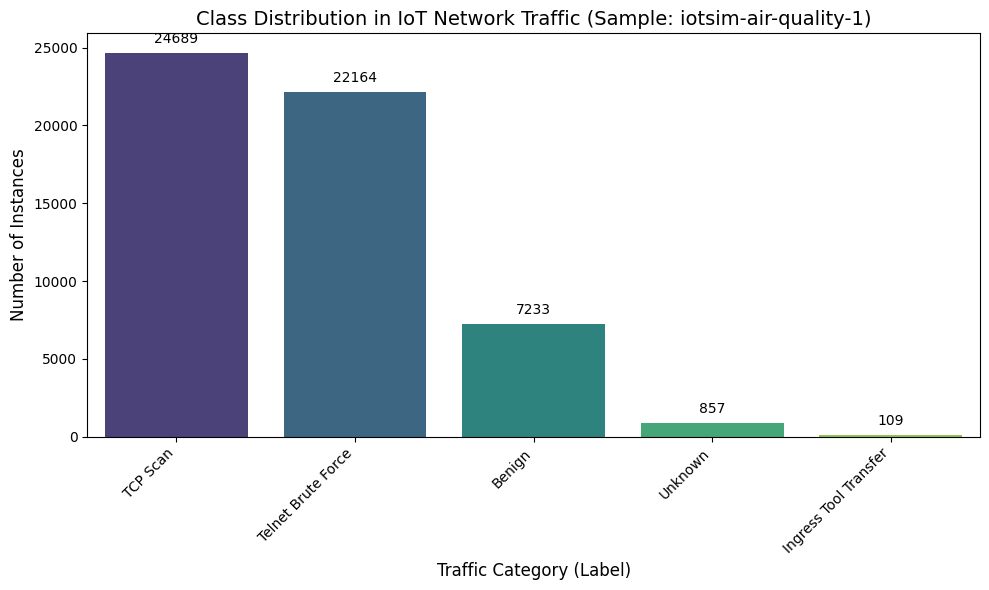

In [3]:
# Cell 3: Exploratory Data Analysis - Class Distribution and Imbalance Quantification

import matplotlib.pyplot as plt
import seaborn as sns

# Isolate the target variable to analyze the distribution
target_column = 'label'
class_counts = df_sample[target_column].value_counts()
class_percentages = df_sample[target_column].value_counts(normalize=True) * 100

# Output the statistical summary of the class distribution
print("Quantitative Analysis of Class Distribution:")
for label, count in class_counts.items():
    percentage = class_percentages[label]
    print(f" - Class '{label}': {count} instances ({percentage:.2f}%)")

# Generate a visual representation to highlight data imbalance
plt.figure(figsize=(10, 6))
# Suppress the FutureWarning by avoiding passing palette without hue
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette="viridis", legend=False)

plt.title("Class Distribution in IoT Network Traffic (Sample: iotsim-air-quality-1)", fontsize=14)
plt.xlabel("Traffic Category (Label)", fontsize=12)
plt.ylabel("Number of Instances", fontsize=12)
plt.xticks(rotation=45, ha='right')

# Annotate bars with exact numerical counts for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [4]:
# Cell 4: Comprehensive Data Preprocessing - Cleaning, Imputation, and Type Conversion

# 1. Define columns to exclude (identifiers, timestamps, complex strings, and noisy checksums)
columns_to_drop = [
    'frame.time', 'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 
    'frame.protocols', 'tcp.options', 'ip.checksum', 'tcp.checksum'
]

# Create a clean working copy by dropping the specified columns
df_clean = df_sample.drop(columns=columns_to_drop, errors='ignore')

# 2. Impute missing values (NaN) with 0. 
df_clean = df_clean.fillna(0)

# 3. Convert hexadecimal flag strings (e.g., '0x02') to analytical numerical formats (integers)
def hex_to_int(val):
    try:
        if isinstance(val, str) and val.startswith('0x'):
            return int(val, 16)
        return float(val)
    except:
        return 0

df_clean['ip.flags'] = df_clean['ip.flags'].apply(hex_to_int)
df_clean['tcp.flags'] = df_clean['tcp.flags'].apply(hex_to_int)

# 4. Output the structural changes and verify final data types
print("Status: Comprehensive Preprocessing Completed.")
print(f"Original dimensionality: {df_sample.shape}")
print(f"Cleaned dimensionality: {df_clean.shape}\n")

print("Final Data Type Verification (All features must be numerical except 'label'):")
print(df_clean.dtypes)

Status: Comprehensive Preprocessing Completed.
Original dimensionality: (55052, 23)
Cleaned dimensionality: (55052, 14)

Final Data Type Verification (All features must be numerical except 'label'):
frame.len                        int64
ip.flags                         int64
ip.ttl                           int64
ip.proto                         int64
ip.tos                         float64
tcp.srcport                    float64
tcp.dstport                    float64
tcp.flags                      float64
tcp.window_size_value          float64
tcp.window_size_scalefactor    float64
tcp.pdu.size                   float64
udp.srcport                    float64
udp.dstport                    float64
label                              str
dtype: object


In [5]:
# Cell 5: Baseline Model Implementation and Evaluation on Imbalanced Data

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# 1. Isolate feature space (X) and target variable (y)
X = df_clean.drop(columns=['label'])
y = df_clean['label']

# 2. Encode categorical target labels into numerical arrays
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Partition the dataset into training and testing subsets (80/20 split)
# Stratification ensures that minority classes are proportionally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set dimensions: {X_train.shape}")
print(f"Testing set dimensions: {X_test.shape}\n")

# 4. Initialize and train the baseline classification model (Random Forest)
print("Training Baseline Model (Random Forest Classifier)...")
# n_jobs=-1 utilizes all available CPU cores to accelerate training
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

# 5. Execute predictions on the unseen testing set
y_pred = rf_baseline.predict(X_test)

# 6. Output the comprehensive classification report to evaluate algorithmic performance
print("\nBaseline Model Evaluation (Classification Report):")
target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

Training set dimensions: (44041, 13)
Testing set dimensions: (11011, 13)

Training Baseline Model (Random Forest Classifier)...

Baseline Model Evaluation (Classification Report):
                       precision    recall  f1-score   support

               Benign       1.00      1.00      1.00      1447
Ingress Tool Transfer       1.00      0.86      0.93        22
             TCP Scan       0.97      0.97      0.97      4938
   Telnet Brute Force       0.97      0.96      0.96      4433
              Unknown       1.00      1.00      1.00       171

             accuracy                           0.97     11011
            macro avg       0.99      0.96      0.97     11011
         weighted avg       0.97      0.97      0.97     11011

